# 第4章: 言語解析

問題30から問題35までは、以下の文章`text`（太宰治の『走れメロス』の冒頭部分）に対して、言語解析を実施せよ。問題36から問題39までは、国家を説明した文書群（日本語版ウィキペディア記事から抽出したテキスト群）をコーパスとして、言語解析を実施せよ。

In [8]:
text = """
メロスは激怒した。
必ず、かの邪智暴虐の王を除かなければならぬと決意した。
メロスには政治がわからぬ。
メロスは、村の牧人である。
笛を吹き、羊と遊んで暮して来た。
けれども邪悪に対しては、人一倍に敏感であった。
"""

## 30. 動詞
文章`text`に含まれる動詞をすべて表示せよ。

In [1]:
!pip install janome

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.7/19.7 MB 75.7 MB/s eta 0:00:00


In [9]:
from janome.tokenizer import Tokenizer

t = Tokenizer()

# 文章を単語ごとに分割して品詞を確認する
for token in t.tokenize(text):
  res = token.part_of_speech.split(",")

  if (res[0] == "動詞"):
    print(token.surface)

し
除か
なら
し
わから
吹き
遊ん
暮し
来


## 31. 動詞の原型
文章`text`に含まれる動詞と、その原型をすべて表示せよ。

In [47]:
for token in t.tokenize(text):
  res = token.part_of_speech.split(",")

  if (res[0] == "動詞"):
    print(token.base_form)

する
除く
なる
する
わかる
吹く
遊ぶ
暮す
来る


## 32. 「AのB」
文章`text`において、2つの名詞が「の」で連結されている名詞句をすべて抽出せよ。

In [48]:
data = t.tokenize(text)
res = []

for i,token in enumerate(data):
  part_of_speech = token.part_of_speech.split(",")[0]
  res.append([token.surface, part_of_speech])

  if (len(res) >= 3):

    if (res[1][0] == "の"):
      if (res[0][1] == "名詞") and (res[2][1] == "名詞"):
        print(res[0][0])
        print(res[2][0])

    del res[0]

暴虐
王
村
牧人


## 33. 係り受け解析

文章`text`に係り受け解析を適用し、係り元と係り先のトークン（形態素や文節などの単位）をタブ区切り形式ですべて抽出せよ。

In [2]:
!pip install -U ginza ja-ginza

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 1.6 MB/s eta 0:00:00


In [3]:
import spacy

# エラーを回避するための設定（config）を定義
config = {
    "components": {
        "compound_splitter": {
            "split_mode": "C",
        }
    }
}

# configを渡してGiNZA（日本語モデル）を読み込む
nlp = spacy.load("ja_ginza", config=config)

In [51]:
# 2. 解析したいテキストを渡す
doc = nlp(text.replace("\n", ""))

# 3. 係り受けの結果を1単語ずつ取り出して表示する
for token in doc:
    # token.text      : その単語（係り元）
    # token.head.text : どこにかかっているか（係り先）
    # token.dep_      : どういう関係か（主語、目的語など）
    print(f"{token.text} -> {token.head.text} ({token.dep_})")

メロス -> 激怒 (nsubj)
は -> メロス (case)
激怒 -> 激怒 (ROOT)
し -> 激怒 (aux)
た -> 激怒 (aux)
。 -> 激怒 (punct)
必ず -> 除か (advmod)
、 -> 必ず (punct)
かの -> 暴虐 (det)
邪智 -> 暴虐 (compound)
暴虐 -> 王 (nmod)
の -> 暴虐 (case)
王 -> 除か (obj)
を -> 王 (case)
除か -> 決意 (advcl)
なけれ -> 除か (aux)
ば -> なけれ (fixed)
なら -> なけれ (fixed)
ぬ -> なけれ (fixed)
と -> 除か (case)
決意 -> 決意 (ROOT)
し -> 決意 (aux)
た -> 決意 (aux)
。 -> 決意 (punct)
メロス -> わから (obl)
に -> メロス (case)
は -> メロス (case)
政治 -> わから (nsubj)
が -> 政治 (case)
わから -> わから (ROOT)
ぬ -> わから (aux)
。 -> わから (punct)
メロス -> 牧人 (nsubj)
は -> メロス (case)
、 -> メロス (punct)
村 -> 牧人 (nmod)
の -> 村 (case)
牧人 -> 牧人 (ROOT)
で -> 牧人 (cop)
ある -> で (fixed)
。 -> 牧人 (punct)
笛 -> 吹き (obj)
を -> 笛 (case)
吹き -> 暮し (advcl)
、 -> 吹き (punct)
羊 -> 遊ん (obl)
と -> 羊 (case)
遊ん -> 暮し (advcl)
で -> 遊ん (mark)
暮し -> 暮し (ROOT)
て -> 暮し (mark)
来 -> て (fixed)
た -> 暮し (aux)
。 -> 暮し (punct)
けれど -> 敏感 (cc)
も -> けれど (fixed)
邪悪 -> 敏感 (obl)
に -> 邪悪 (case)
対し -> に (fixed)
ては -> に (fixed)
、 -> 邪悪 (punct)
人 -> 倍 (compound)
一 -> 倍 (nummod)
倍 ->

## 34. 主述の関係
文章`text`において、「メロス」が主語であるときの述語を抽出せよ。

In [52]:
# 2. 解析したいテキストを渡す
doc = nlp(text.replace("\n", ""))

# 3. 係り受けの結果を1単語ずつ取り出して表示する
for token in doc:
    if (token.dep_ == "nsubj") and (token.text == "メロス"):
      print(token.head.text)

激怒
牧人


## 35. 係り受け木
「メロスは激怒した。」の係り受け木を可視化せよ。

In [53]:
from spacy import displacy

text = "メロスは激怒した。"
doc = nlp(text)

displacy.render(doc,
                style="dep"   # 描画スタイルの指定　dep -> 係り受け
                )

## 36. 単語の出現頻度

問題36から39までは、Wikipediaの記事を以下のフォーマットで書き出したファイル[jawiki-country.json.gz](/data/jawiki-country.json.gz)をコーパスと見なし、統計的な分析を行う。

* 1行に1記事の情報がJSON形式で格納される
* 各行には記事名が"title"キーに、記事本文が"text"キーの辞書オブジェクトに格納され、そのオブジェクトがJSON形式で書き出される
* ファイル全体はgzipで圧縮される

まず、第3章の処理内容を参考に、Wikipedia記事からマークアップを除去し、各記事のテキストを抽出せよ。そして、コーパスにおける単語（形態素）の出現頻度を求め、出現頻度の高い20語とその出現頻度を表示せよ。

In [4]:
!pip install mecab-python3 unidic-lite

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 MB 9.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 591.4/591.4 kB 31.6 MB/s eta 0:00:00
  Created wheel for unidic-lite: filename=unidic_lite-1.0.8-py3-none-any.whl size=47658817 sha256=616f7b049ed50260391c58237d4677800b71c798123c4e37f19fad2f5c3eac05
  Stored in directory: /root/.cache/pip/wheels/5e/1f/0f/4d43887e5476d956fae828ee9b6687becd5544d68b51ed633d
Successfully built unidic-lite


In [5]:
import re
import json

import MeCab
from collections import Counter

In [10]:
word_counts = Counter()
t = Tokenizer()

pattern = re.compile(r"[一-龥ぁ-んァ-ヶ]")

with open("jawiki-country.json", 'r') as f:
  for line in f:
      line = json.loads(line)["text"]
      data = t.tokenize(line)

      for word in data:
        res = word.part_of_speech.split(",")
        pos = res[0]
        original = word.base_form

        if ((pos in ["名詞", "動詞", "形容詞"]) and (bool(pattern.search(original)) == True)):
          word_counts[(original, pos)] += 1

for i, ((word, pos), count) in enumerate(word_counts.most_common(20), 1):
    print(f"{i}: {word} ({count}回)")

1: する (48174回)
2: 年 (30229回)
3: れる (18574回)
4: いる (17519回)
5: 月 (13705回)
6: 日 (10508回)
7: 人 (10135回)
8: 国 (9082回)
9: なる (7570回)
10: ある (5835回)
11: 語 (5803回)
12: 的 (5263回)
13: 世界 (4819回)
14: こと (4642回)
15: リンク (4414回)
16: 日本 (4343回)
17: 大統領 (4056回)
18: 政府 (3646回)
19: ため (3551回)
20: 州 (3440回)


## 37. 名詞の出現頻度
コーパスにおける名詞の出現頻度を求め、出現頻度の高い20語とその出現頻度を表示せよ。

In [11]:
i = 1
for (word, pos) in word_counts:
  count = word_counts[(word, pos)]

  if (pos == "名詞"):
    print(f"{i}: {word} ({count}回)")
    i += 1

  if (i > 20):
    break

1: 主 (619回)
2: 現代 (508回)
3: エジプト (448回)
4: アラブ (620回)
5: 共和 (3351回)
6: 国 (9082回)
7: 古代 (289回)
8: 基礎 (574回)
9: 情報 (732回)
10: 略 (232回)
11: 名 (1218回)
12: 漢字 (267回)
13: 書き (11回)
14: 埃及 (3回)
15: 日本語 (925回)
16: 国名 (1130回)
17: 公式 (632回)
18: 国旗 (389回)
19: 画像 (806回)
20: 章 (1434回)


## 38. TF・IDF
日本に関する記事における名詞のTF・IDFスコアを求め、TF・IDFスコア上位20語とそのTF, IDF, TF・IDFを表示せよ。

In [12]:
import math

In [13]:
t = Tokenizer()

japan = {}
others = {}
total_docs = 0
total = 0

pattern = re.compile(r"[一-龥ぁ-んァ-ヶ]")

with open("jawiki-country.json", "r") as f:
    for line in f:
        line = json.loads(line)
        total_docs += 1

        # 【修正1・4】Tokenオブジェクトのままset()せず、先に条件を満たす名詞（基本形）のリストを作る
        valid_nouns = []
        for word in t.tokenize(line["text"]):
            pos = word.part_of_speech.split(",")[0]
            base = word.base_form

            if (pos == "名詞") and (bool(pattern.search(base)) == True):
                valid_nouns.append(base)

        # 【修正1】日本の記事は純粋なカウント(TF)、それ以外は重複排除(DF)してカウント
        if (line["title"] == "日本"):
            for noun in valid_nouns:
                japan[noun] = japan.get(noun, 0) + 1
                total += 1
        else:
            for noun in set(valid_nouns): # 文字列のリストになったのでset()が正しく機能する
                others[noun] = others.get(noun, 0) + 1


tf_idf_score = []

for word in japan:
    # 【修正3】TFは1のコードに合わせて「純粋な出現回数」にする
    tf = japan[word] / total

    # 【修正2】DFは「他記事での出現数 ＋ 1（日本の記事自身）」にする
    doc_count = others.get(word, 0) + 1

    # 【修正2】1のコードとIDFの計算式を完全に揃える（+ 1 を追加）
    idf = math.log(total_docs / doc_count) + 1

    tf_idf_score.append((tf * idf, tf, idf, word))

tf_idf_score.sort(reverse=True)

# 見やすくするためにヘッダーと小数点のフォーマットを追加
print("単語\tTF-IDF\t\tTF\t\tIDF")
for data in tf_idf_score[:20]:
    print(f"{data[3]}\t{data[0]:.4f}\t\t{data[1]:.4f}\t\t{data[2]:.4f}")

単語	TF-IDF		TF		IDF
日本	0.0365		0.0327		1.1153
年	0.0293		0.0291		1.0081
日	0.0119		0.0116		1.0286
月	0.0115		0.0112		1.0204
県	0.0097		0.0064		1.5298
国	0.0093		0.0092		1.0122
天皇	0.0093		0.0026		3.6231
琉球	0.0090		0.0017		5.4148
的	0.0080		0.0077		1.0412
倭	0.0079		0.0015		5.1271
倭国	0.0078		0.0013		5.8203
中国	0.0071		0.0042		1.7012
沖縄	0.0067		0.0018		3.7408
朝鮮	0.0066		0.0018		3.6231
世界	0.0063		0.0060		1.0370
人	0.0061		0.0060		1.0204
列島	0.0059		0.0014		4.1155
日本書紀	0.0059		0.0009		6.5134
こと	0.0057		0.0055		1.0370
韓国	0.0056		0.0022		2.5816


## 39. Zipfの法則
コーパスにおける単語の出現頻度順位を横軸、その出現頻度を縦軸として、両対数グラフをプロットせよ。

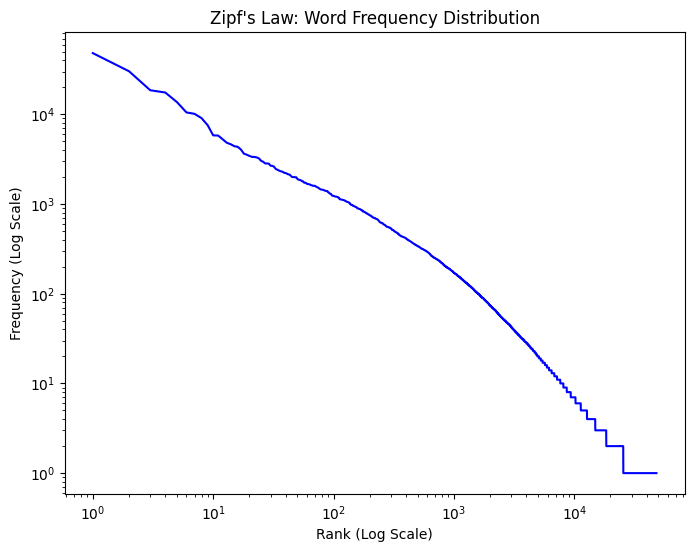

In [14]:
import matplotlib.pyplot as plt

# --- 1. word_counts からグラフ用のデータを抽出する ---

# most_common() を使うと出現頻度順（降順）に並んだデータが取得できるので、
# そこから「頻度（count）」の数値だけをリストとして取り出します。
# ※キーが (単語, 品詞) のタプルでも、ここでは数値しか使わないので問題ありません。
frequencies = [count for item, count in word_counts.most_common()]

# 順位（Rank）のリストを作ります。1位から始まり、単語の種類数まで連番を作ります。
ranks = range(1, len(frequencies) + 1)


# --- 2. グラフの描画 ---

# グラフのサイズを設定
plt.figure(figsize=(8, 6))

# 両対数グラフのプロット
# plt.loglog() を使うと、自動的にX軸とY軸が対数スケールになります。
# linestyle='None' と marker='.' で、線ではなく点でプロットして見やすくします。
plt.loglog(ranks, frequencies, color='b')

# グラフのタイトルと軸ラベルを設定
# （※matplotlibはデフォルトだと日本語が文字化けするため、英語で設定しています）
plt.title("Zipf's Law: Word Frequency Distribution")
plt.xlabel("Rank (Log Scale)")
plt.ylabel("Frequency (Log Scale)")


# グラフを画面に表示
plt.show()